<a href="https://colab.research.google.com/github/acolivera/colabs_VdD/blob/main/modulo2_ejemplos_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ejemplos básicos de visualizaciones en cada una de las bibliotecas mencionads en la teoría.

**#Matplotlib (Gráficos base y precisión)**


---


Imagen: Un gráfico de líneas clásico y limpio, ideal para publicaciones académicas.

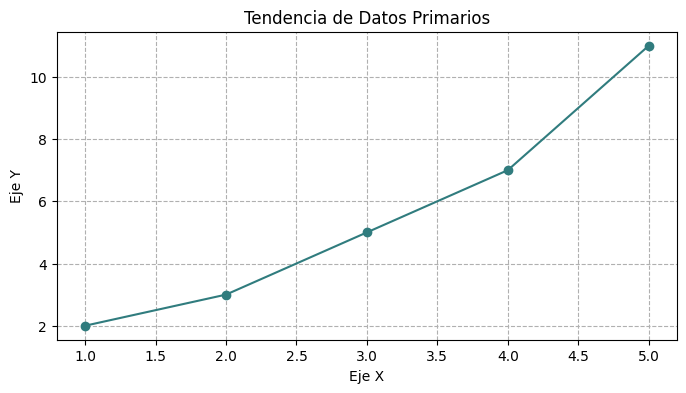

In [1]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [2, 3, 5, 7, 11]

plt.figure(figsize=(8, 4))
plt.plot(x, y, marker='o', color='#307C7E')
plt.title('Tendencia de Datos Primarios')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.grid(True, linestyle='--')
plt.show()

**#Pandas (Visualización Rápida)**


---


Es ideal para cuando estamos explorando los datos y no queremos configurar nada complejo.

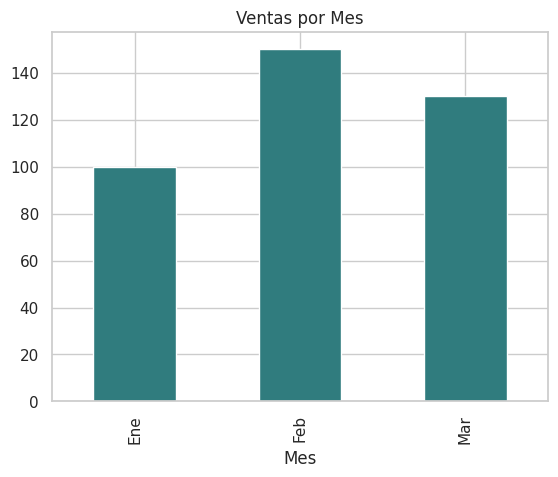

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

data = {'Mes': ['Ene', 'Feb', 'Mar'], 'Ventas': [100, 150, 130]}
df_demo = pd.DataFrame(data)

# El método .plot() usa Matplotlib por detrás
df_demo.plot(kind='bar', x='Mes', y='Ventas', color='#307C7E', legend=False)
plt.title("Ventas por Mes")
plt.show()

**#Seaborn (Visualización Estadística)**


---


Imagen: Un gráfico de distribución con una curva de densidad suave (KDE), muy superior visualmente a un histograma básico.

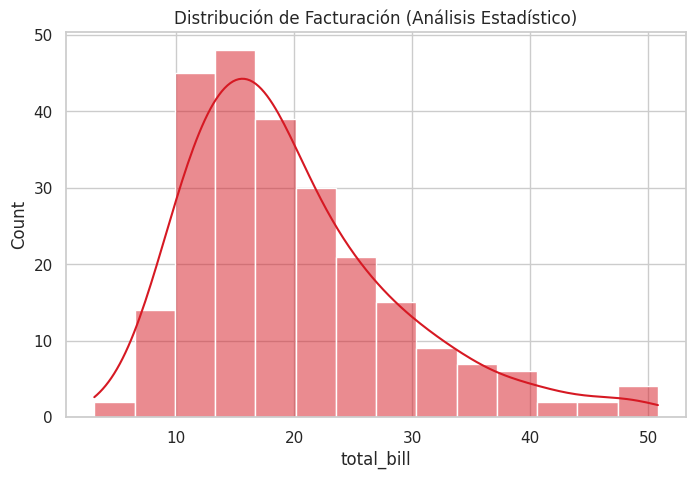

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(data=tips, x="total_bill", kde=True, color='#D61923') # Rojo para resaltar
plt.title('Distribución de Facturación (Análisis Estadístico)')
plt.show()

**#Plotly (Interactividad Web)**


---


Imagen: Un gráfico de burbujas dinámico donde puedes pasar el ratón por encima para ver los valores exactos.

In [3]:
import plotly.express as px

df = px.data.gapminder().query("year==2007")
fig = px.scatter(df, x="gdpPercap", y="lifeExp", size="pop", color="continent",
                 hover_name="country", log_x=True, size_max=60)

fig.update_layout(title='Esperanza de Vida vs PBI (Interactivo)')
fig.show()

**#GeoPandas (Mapas y Territorio)**


---


Imagen: Un mapa temático (coroplético) que muestra regiones coloreadas según una métrica. Es una herramienta muy versatil para estudios por ejemplo de movilidad urbana.

<Axes: >

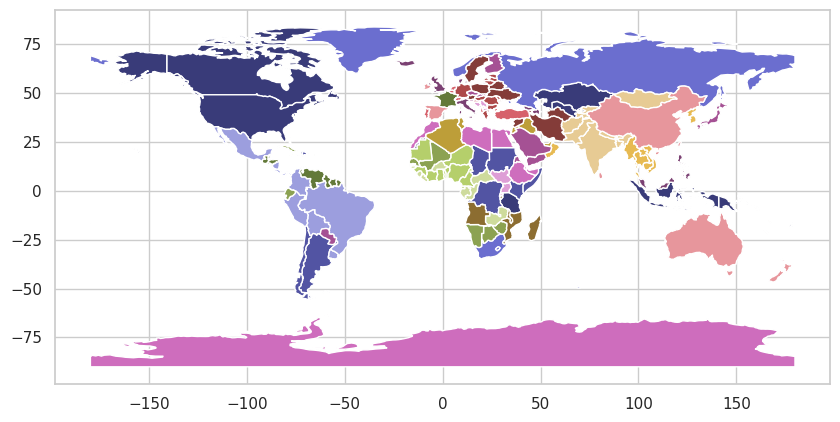

In [32]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Carga de mapa de países
path = "/content/sample_data/ne_110m_admin_0_countries.shp" #en el directorio de trabajo content/sample_data
world = gpd.read_file(path)

world.plot(legend=True, cmap='tab20b', figsize=(10, 6))

**#Bokeh (Interactividad Nativa)**


---


Genera un archivo HTML con herramientas de zoom y guardado integradas.

In [38]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

output_notebook() # Para ver dentro de Jupyter/Colab
p = figure(title="Líneas Simples", x_range=['Ene', 'Feb', 'Mar'], height=300)
p.line(['Ene', 'Feb', 'Mar'], [100, 150, 130], line_width=2, color="#D61923")
show(p)

**#Altair (Gramática de Gráficos)**


---


Se basa en el concepto de "encadenar" métodos. Es muy declarativo.

In [10]:
import altair as alt
from vega_datasets import data

counties = alt.topo_feature(data.us_10m.url, 'counties')
source = data.unemployment.url

alt.Chart(counties).mark_geoshape().encode(
    color='rate:Q'
).transform_lookup(
    lookup='id',
    from_=alt.LookupData(source, 'id', ['rate'])
).project(
    type='albersUsa'
).properties(
    width=500,
    height=300
)

alt.Chart(...)

In [39]:
import altair as alt

chart = alt.Chart(df_demo).mark_bar().encode(
    x='Mes',
    y='Ventas'
).properties(title="Gráfico Declarativo en Altair")
chart.display()

alt.Chart(...)

**#Folium (Mapas Interactivos sobre Leaflet)**


---


Imagen: Un mapa real de la ciudad de Mendoza con marcadores interactivos.

In [35]:
import folium

# Coordenadas aproximadas del ITU - UNCUYO
m = folium.Map(location=[-32.8895, -68.8440], zoom_start=15)
folium.Marker([-32.8805, -68.8778], popup="ITU - Sede Central").add_to(m)

# Para visualizar en un notebook
m

**#Plotly Express - Boxplot (Resumen de Munzner)**


---


Imagen: Un diagrama de caja y bigotes que muestra la mediana y los outliers, tal como se explica en el Módulo 1.

In [36]:
import plotly.express as px

df = px.data.tips()
fig = px.box(df, x="day", y="total_bill", points="all",
             title="Resumen Estadístico por Día (Boxplot)")
fig.show()

**#Yellowbrick (Sintaxis Simple)**


---


Yellowbrick funciona extendiendo la API de scikit-learn. El flujo siempre es: Visualizer -> Fit -> Show. En este ejemplo, visualizamos la importancia de las características en un modelo de clasificación.

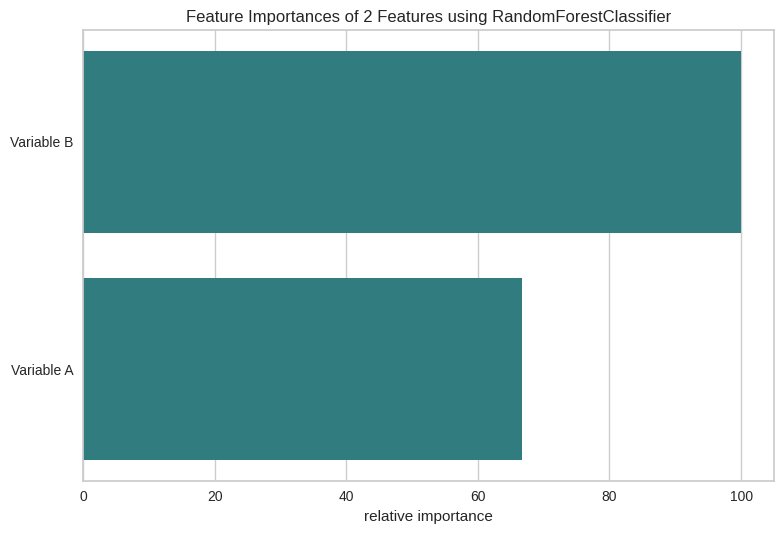

<Axes: title={'center': 'Feature Importances of 2 Features using RandomForestClassifier'}, xlabel='relative importance'>

In [2]:
from sklearn.ensemble import RandomForestClassifier
from yellowbrick.model_selection import FeatureImportances
import matplotlib.pyplot as plt

# Datos ficticios
X = [[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]]
y = [0, 0, 1, 1, 1]
labels = ['Variable A', 'Variable B']

# El visualizador envuelve al modelo
model = RandomForestClassifier(n_estimators=10)
viz = FeatureImportances(model, labels=labels, colors=['#307C7E']) #

viz.fit(X, y)
viz.show()

**#Geoplot**


---

Herramienta útil para observar mapas

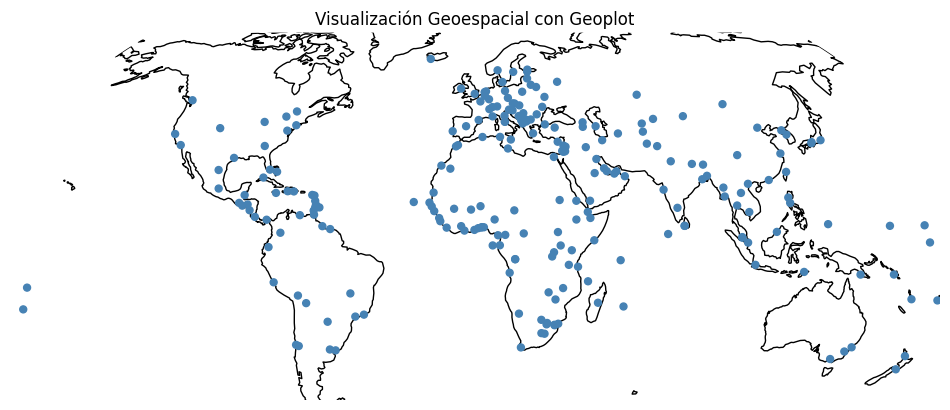

In [10]:
#!apt install python3-cartopy # se usa la primera vez para instalar la libreria
#!pip install geoplot # se usa la primera vez para instalar la libreria
#!pip install geodatasets # se usa la primera vez para instalar la libreria
import geoplot as gplt
import geodatasets as data
import geopandas as gpd
import matplotlib.pyplot as plt

# Cargar un dataset de ejemplo (puedes usar tus datos de movilidad)
world = gpd.read_file(data.get_url('naturalearth.land'))
cities = gpd.read_file(data.get_url('naturalearth_cities'))

# Crear un mapa de puntos (Pointplot) sobre una base geográfica
ax = gplt.polyplot(world, figsize=(12, 8), projection=gplt.crs.Robinson())
gplt.pointplot(cities, ax=ax)

plt.title("Visualización Geoespacial con Geoplot")
plt.show()